# Analisis Kemampuan Numerasi Siswa SMP dan Faktor-Faktor yang Memengaruhinya Berdasarkan Asesmen Nasional

# 1. IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 120

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer

# regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

# clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# statistik
from scipy import stats

# 2. LOAD DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 import pandas as pd

jalur_file = '/content/drive/MyDrive/UNNES SEMESTER 6/Data Mining/PROYEK ARTIKEL 2 (KEMENDIKDASMEN)/KEMENDIKDASMEN/rapor-publik-asesmen-nasional-2025-peserta-didik-2025-smp-mts-sederajat.xlsx'

df = pd.read_excel(jalur_file, sheet_name='rapor_publik')

print(f"Shape data mentah terbaru: {df.shape}")

Shape data mentah terbaru: (526433, 139)


# 3. EKSPLORASI AWAL DATA

In [ ]:
print("=== INFO KOLOM ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

print("\n=== DAFTAR KOLOM ===")
for i, col in enumerate(df.columns):
    print(f"  [{i:3d}] {col}")

=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526433 entries, 0 to 526432
Columns: 139 entries, kd_sekolah to IASP
dtypes: float64(103), int64(2), object(34)
memory usage: 558.3+ MB
None

=== STATISTIK DESKRIPTIF ===
         kd_sekolah       kd_kokab  proporsi_pendidik_min_s1  \
count  5.264330e+05  526433.000000             402296.000000   
mean   3.462888e+06     257.387637                  0.974367   
std    8.777180e+05     148.550880                  0.086546   
min    3.100001e+06       1.000000                  0.000000   
25%    3.103845e+06     130.000000                  1.000000   
50%    3.107750e+06     254.000000                  1.000000   
75%    4.100073e+06     389.000000                  1.000000   
max    9.700001e+06     514.000000                  1.000000   

       proporsi_pendidik_sertifikasi  jumlah_peserta_didik  jumlah_pendidik  \
count                  402296.000000         402320.000000    402320.000000   
mean                     

# 4. MEMILIH VARIABEL YANG DIGUNAKAN

In [ ]:
KOLOM = [
    'NUM',
    'LIT',
    'SES_siswa',
    'SES_sekolah',
    'ketersediaan_internet',
    'jumlah_komp_milik',
    'jumlah_perpus',
    'jumlah_pendidik',
    'rasio_pendidik_peserta_didik'
]

data = df[KOLOM].copy()

print(f"\nDataset penelitian: {data.shape[0]} baris × {data.shape[1]} kolom")
data.head()


Dataset penelitian: 526433 baris × 9 kolom


,NUM,LIT,SES_siswa,SES_sekolah,ketersediaan_internet,jumlah_komp_milik,jumlah_perpus,jumlah_pendidik,rasio_pendidik_peserta_didik
0,76.6660,100.0000,42.07,75.09,Ada,0.0,0.0,8.0,0.0419
1,40.1587,50.1607,51.64,75.09,Ada,0.0,0.0,8.0,0.0419
2,94.6696,100.0000,58.32,75.09,Ada,0.0,0.0,8.0,0.0419
3,76.9994,71.6650,50.00,75.09,Ada,0.0,0.0,8.0,0.0419
4,67.1641,53.3280,48.26,75.09,Ada,0.0,0.0,8.0,0.0419


# 5. Cek Tipe Data

In [ ]:
print(data.dtypes)

NUM                             float64
LIT                             float64
SES_siswa                       float64
SES_sekolah                     float64
ketersediaan_internet            object
jumlah_komp_milik               float64
jumlah_perpus                   float64
jumlah_pendidik                 float64
rasio_pendidik_peserta_didik    float64
dtype: object


# 6. Menangani Data Kategorikal dan Missing Value

In [ ]:
from sklearn.impute import SimpleImputer

# copy data supaya aman
data_clean = data.copy()

# 7. Identifikasi Kolom Numerik dan Kategorikal

In [ ]:
kolom_numerik = data_clean.select_dtypes(
    include=['int64', 'float64']
).columns

kolom_kategorikal = data_clean.select_dtypes(
    include=['object']
).columns

print("Kolom Numerik:")
print(list(kolom_numerik))

print("\nKolom Kategorikal:")
print(list(kolom_kategorikal))

Kolom Numerik:
['NUM', 'LIT', 'SES_siswa', 'SES_sekolah', 'jumlah_komp_milik', 'jumlah_perpus', 'jumlah_pendidik', 'rasio_pendidik_peserta_didik']

Kolom Kategorikal:
['ketersediaan_internet']


# 8. Ubah Kolom Kategorikal Menjadi Numerik

In [ ]:
for col in kolom_kategorikal:
    print(f"\nEncoding kolom: {col}")

    data_clean[col] = data[col]

    data_clean[col] = data_clean[col].str.strip().str.title()
    print("Sebelum di-encode (Teks Seragam):", data_clean[col].unique()[:10])

    data_clean[col] = data_clean[col].astype('category').cat.codes
    print("Sesudah di-encode (Angka):", data_clean[col].unique()[:10])


Encoding kolom: ketersediaan_internet
Sebelum di-encode (Teks Seragam): ['Ada' nan 'Tidak Ada']
Sesudah di-encode (Angka): [ 0 -1  1]


# 9. Cek Missing Value Sebelum

In [ ]:
print("\n=== MISSING VALUE SEBELUM ===")

missing = data_clean.isnull().sum()

if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Tidak ada missing value.")


=== MISSING VALUE SEBELUM ===
NUM                               3262
LIT                               2180
SES_siswa                         3260
jumlah_komp_milik               124113
jumlah_perpus                   124113
jumlah_pendidik                 124113
rasio_pendidik_peserta_didik    124113
dtype: int64


# 10. Imputasi Missing Value

In [ ]:
imputer = SimpleImputer(strategy='median')

data_arr = imputer.fit_transform(data_clean)

# ubah kembali ke dataframe
data_clean = pd.DataFrame(
    data_arr,
    columns=data_clean.columns
)

# 11. Cek Missing Value Setelah

In [ ]:
print("\n=== MISSING VALUE SETELAH ===")

print(data_clean.isnull().sum())


=== MISSING VALUE SETELAH ===
NUM                             0
LIT                             0
SES_siswa                       0
SES_sekolah                     0
ketersediaan_internet           0
jumlah_komp_milik               0
jumlah_perpus                   0
jumlah_pendidik                 0
rasio_pendidik_peserta_didik    0
dtype: int64


# 12. Cek Hasil Akhir

In [ ]:
print("\n=== INFO DATA CLEAN ===")

print(data_clean.info())

data_clean.head()


=== INFO DATA CLEAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526433 entries, 0 to 526432
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   NUM                           526433 non-null  float64
 1   LIT                           526433 non-null  float64
 2   SES_siswa                     526433 non-null  float64
 3   SES_sekolah                   526433 non-null  float64
 4   ketersediaan_internet         526433 non-null  float64
 5   jumlah_komp_milik             526433 non-null  float64
 6   jumlah_perpus                 526433 non-null  float64
 7   jumlah_pendidik               526433 non-null  float64
 8   rasio_pendidik_peserta_didik  526433 non-null  float64
dtypes: float64(9)
memory usage: 36.1 MB
None


,NUM,LIT,SES_siswa,SES_sekolah,ketersediaan_internet,jumlah_komp_milik,jumlah_perpus,jumlah_pendidik,rasio_pendidik_peserta_didik
0,76.6660,100.0000,42.07,75.09,0.0,0.0,0.0,8.0,0.0419
1,40.1587,50.1607,51.64,75.09,0.0,0.0,0.0,8.0,0.0419
2,94.6696,100.0000,58.32,75.09,0.0,0.0,0.0,8.0,0.0419
3,76.9994,71.6650,50.00,75.09,0.0,0.0,0.0,8.0,0.0419
4,67.1641,53.3280,48.26,75.09,0.0,0.0,0.0,8.0,0.0419


# 13. Cek dan Hapus Duplikat

In [ ]:
print(f"\nJumlah duplikat: {data_clean.duplicated().sum()}")
data_clean = data_clean.drop_duplicates().reset_index(drop=True)
print(f"Shape setelah hapus duplikat: {data_clean.shape}")


Jumlah duplikat: 150
Shape setelah hapus duplikat: (526283, 9)


# 14. Cek Outlier

In [ ]:
print("=== OUTLIER PER KOLOM (Metode IQR) ===")
# Ambil hanya kolom numerik dari data_clean
kolom_numerik = data_clean.select_dtypes(include=['int64', 'float64']).columns

for col in kolom_numerik:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    n_out = ((data_clean[col] < batas_bawah) |
     (data_clean[col] > batas_atas)).sum()
    persen = (n_out / len(data_clean)) * 100
    print(f"{col:35s}: {n_out} outlier ({persen:.1f}%)")

=== OUTLIER PER KOLOM (Metode IQR) ===
NUM                                : 3980 outlier (0.8%)
LIT                                : 7226 outlier (1.4%)
SES_siswa                          : 6198 outlier (1.2%)
SES_sekolah                        : 24589 outlier (4.7%)
ketersediaan_internet              : 161832 outlier (30.7%)
jumlah_komp_milik                  : 44366 outlier (8.4%)
jumlah_perpus                      : 67908 outlier (12.9%)
jumlah_pendidik                    : 43117 outlier (8.2%)
rasio_pendidik_peserta_didik       : 53844 outlier (10.2%)


# 15. Hapus Outlier Hanya Pada Target NUM

In [ ]:
Q1_num = data_clean['NUM'].quantile(0.25)
Q3_num = data_clean['NUM'].quantile(0.75)
IQR_num = Q3_num - Q1_num

batas_bawah_num = Q1_num - 1.5 * IQR_num
batas_atas_num = Q3_num + 1.5 * IQR_num

data_clean = data_clean[
    (data_clean['NUM'] >= batas_bawah_num) &
    (data_clean['NUM'] <= batas_atas_num)
].reset_index(drop=True)

print(f"\nShape setelah hapus outlier NUM: {data_clean.shape}")

data = data_clean.copy()


Shape setelah hapus outlier NUM: (522303, 9)


# 16. Analisis Korelasi

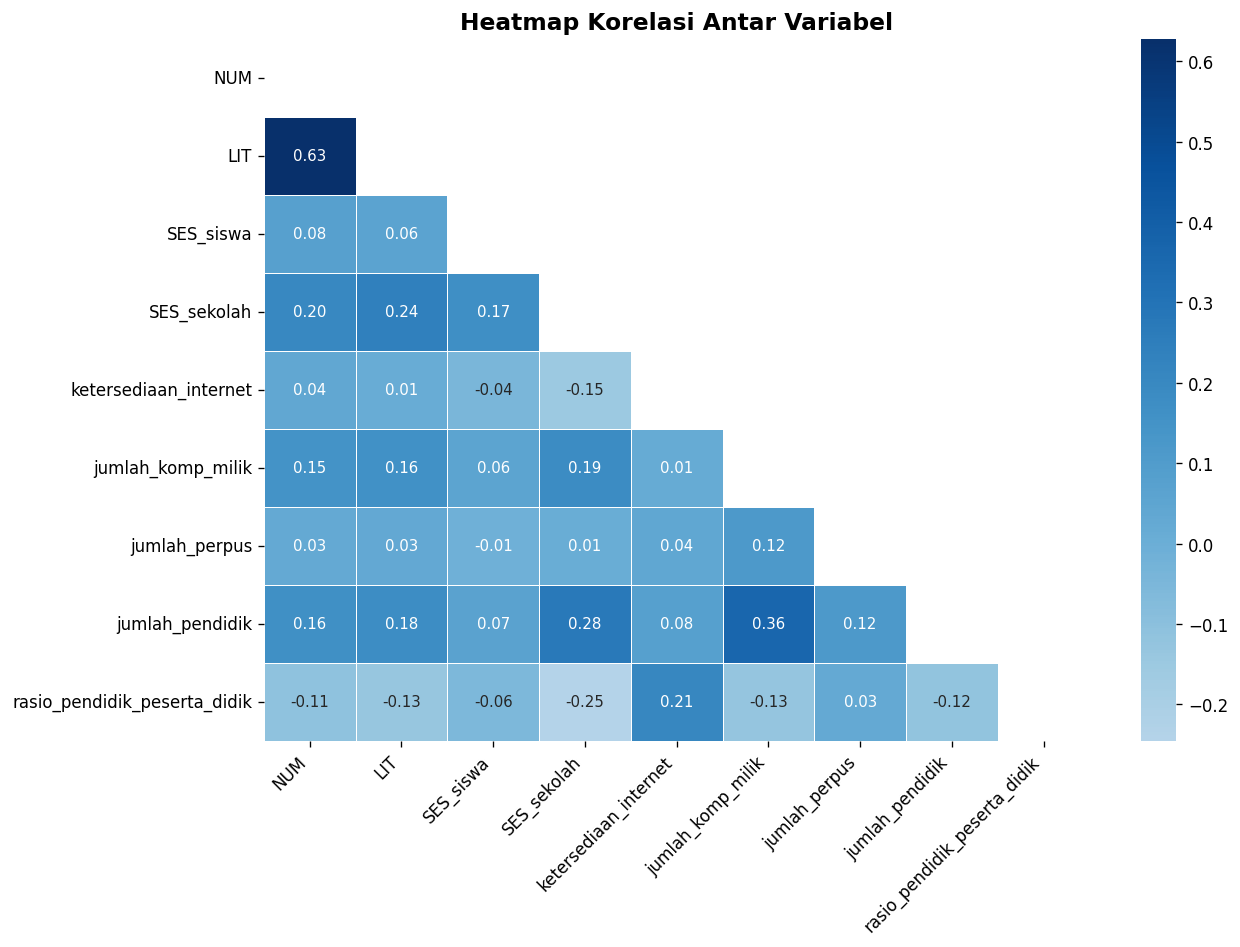

In [ ]:
corr = data.select_dtypes(
    include=['int64', 'float64']
).corr()

plt.figure(figsize=(11, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title(
    'Heatmap Korelasi Antar Variabel',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 17. Korelasi dengan NUM

In [ ]:
print("\n=== KORELASI TIAP VARIABEL DENGAN NUM ===")

corr_num = corr['NUM'].drop('NUM').sort_values(
    ascending=False
)

print(corr_num)


=== KORELASI TIAP VARIABEL DENGAN NUM ===
LIT                             0.627763
SES_sekolah                     0.202251
jumlah_pendidik                 0.162180
jumlah_komp_milik               0.147502
SES_siswa                       0.077812
ketersediaan_internet           0.035152
jumlah_perpus                   0.029227
rasio_pendidik_peserta_didik   -0.109049
Name: NUM, dtype: float64


# 18. Memisahkan Fitur dan Target

In [ ]:
FITUR = [
    'LIT',
    'SES_siswa',
    'SES_sekolah',
    'ketersediaan_internet',
    'jumlah_komp_milik',
    'jumlah_perpus',
    'jumlah_pendidik',
    'rasio_pendidik_peserta_didik'
]

# pastikan semua fitur ada
print("\nKolom tersedia:")
print(data.columns.tolist())

X = data[FITUR].copy()

# target
y = data['NUM'].copy()

print(f"\nDimensi X : {X.shape}")
print(f"Dimensi y : {y.shape}")


Kolom tersedia:
['NUM', 'LIT', 'SES_siswa', 'SES_sekolah', 'ketersediaan_internet', 'jumlah_komp_milik', 'jumlah_perpus', 'jumlah_pendidik', 'rasio_pendidik_peserta_didik']

Dimensi X : (522303, 8)
Dimensi y : (522303,)


# 19. Split Data (Sebelum Normalisasi)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set : {X_train.shape[0]} baris")
print(f"Testing set  : {X_test.shape[0]} baris")


Training set : 417842 baris
Testing set  : 104461 baris


# 20. Normalisasi Data

In [ ]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=FITUR)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=FITUR)

print("Normalisasi selesai (fit hanya pada training set).")

Normalisasi selesai (fit hanya pada training set).


# REGRESI

# 21. Model Regresi


In [ ]:
models_reg = {
    'Linear Regression' : LinearRegression(),
    'Random Forest Reg' : RandomForestRegressor(n_estimators=100, random_state=42)
}

hasil_reg = {}
for nama, model in models_reg.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    hasil_reg[nama] = {
        'model'  : model,
        'y_pred' : y_pred,
        'RMSE'   : np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE'    : mean_absolute_error(y_test, y_pred),
        'R2'     : r2_score(y_test, y_pred)
    }
    print(f"\n=== {nama} ===")
    print(f"  RMSE     : {hasil_reg[nama]['RMSE']:.4f}")
    print(f"  MAE      : {hasil_reg[nama]['MAE']:.4f}")
    print(f"  R² Score : {hasil_reg[nama]['R2']:.4f}")


=== Linear Regression ===
  RMSE     : 10.6337
  MAE      : 8.3082
  R² Score : 0.3991

=== Random Forest Reg ===
  RMSE     : 10.5441
  MAE      : 8.2787
  R² Score : 0.4092


# 22. Koefisien Regresi Linear


=== KOEFISIEN REGRESI LINEAR ===
                    Variabel  Koefisien
                         LIT   8.368747
                 SES_sekolah   0.535439
       ketersediaan_internet   0.497516
                   SES_siswa   0.430936
           jumlah_komp_milik   0.407054
             jumlah_pendidik   0.333383
               jumlah_perpus   0.040793
rasio_pendidik_peserta_didik  -0.245816


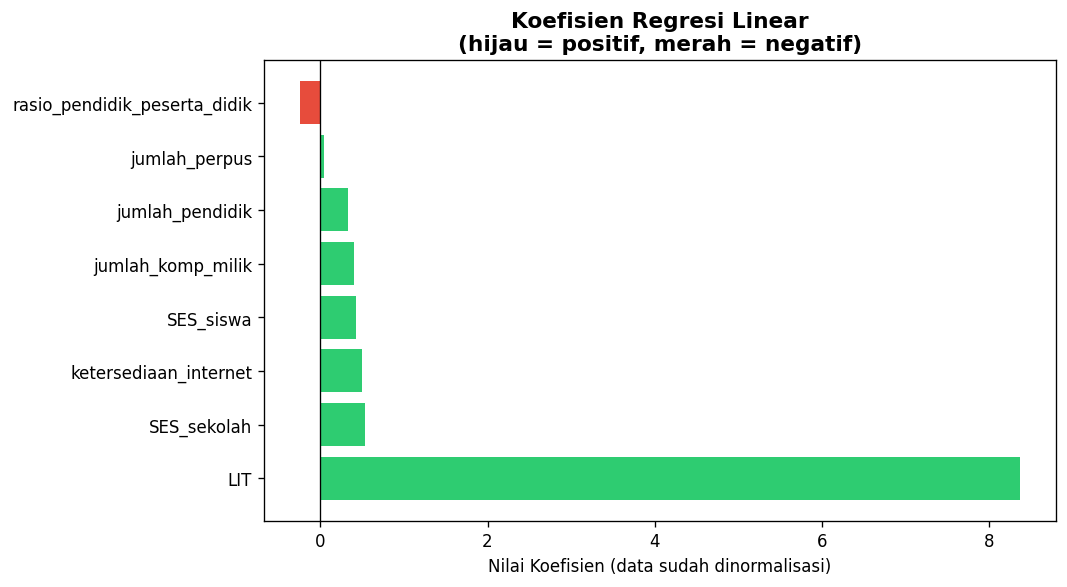

In [ ]:
lr_model = hasil_reg['Linear Regression']['model']

coef = pd.DataFrame({
    'Variabel'   : FITUR,
    'Koefisien'  : lr_model.coef_
}).sort_values('Koefisien', ascending=False).reset_index(drop=True)

print("\n=== KOEFISIEN REGRESI LINEAR ===")
print(coef.to_string(index=False))

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef['Koefisien']]

plt.figure(figsize=(9, 5))
bars = plt.barh(coef['Variabel'], coef['Koefisien'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Koefisien Regresi Linear\n(hijau = positif, merah = negatif)',
          fontsize=13, fontweight='bold')
plt.xlabel('Nilai Koefisien (data sudah dinormalisasi)')
plt.tight_layout()
plt.show()

# 23. Visualisasi: Aktual VS Prediksi

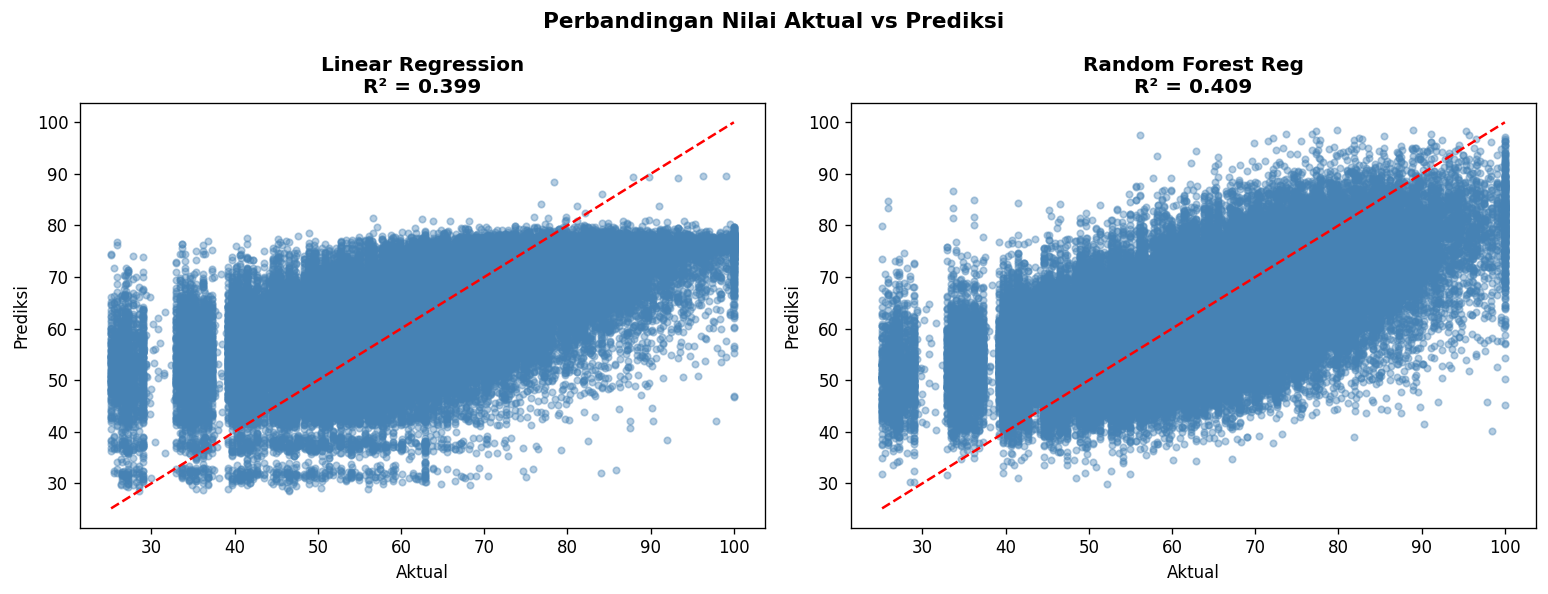

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nama, res) in zip(axes, hasil_reg.items()):
    ax.scatter(y_test, res['y_pred'], alpha=0.4, s=15, color='steelblue')
    min_val = min(y_test.min(), res['y_pred'].min())
    max_val = max(y_test.max(), res['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
    ax.set_title(f"{nama}\nR² = {res['R2']:.3f}", fontweight='bold')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')

plt.suptitle('Perbandingan Nilai Aktual vs Prediksi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# KLASIFIKASI

# 24. Membuat Kategori Numerasi

In [ ]:
q33 = y.quantile(0.33)
q67 = y.quantile(0.67)

def label_numerasi(skor):
    if skor <= q33:
        return 0   # Rendah
    elif skor <= q67:
        return 1   # Sedang
    else:
        return 2   # Tinggi

y_cat = y.apply(label_numerasi).astype(int)
label_names = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}

print(f"Batas kategori:")
print(f"  Rendah  : NUM ≤ {q33:.2f}")
print(f"  Sedang  : {q33:.2f} < NUM ≤ {q67:.2f}")
print(f"  Tinggi  : NUM > {q67:.2f}")
print("\nDistribusi kelas:")
print(y_cat.map(label_names).value_counts())

Batas kategori:
  Rendah  : NUM ≤ 56.66
  Sedang  : 56.66 < NUM ≤ 69.00
  Tinggi  : NUM > 69.00

Distribusi kelas:
NUM
Sedang    177960
Rendah    174538
Tinggi    169805
Name: count, dtype: int64


# 25.  Split dan Normalisasi untuk Classification

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

print(f"\nTraining : {X_train_c.shape[0]} baris")
print(f"Testing  : {X_test_c.shape[0]} baris")


Training : 417842 baris
Testing  : 104461 baris


# 26. Decision Tree


=== DECISION TREE ===
Accuracy : 0.5781
              precision    recall  f1-score   support

      Rendah       0.62      0.66      0.64     34908
      Sedang       0.45      0.44      0.44     35592
      Tinggi       0.66      0.64      0.65     33961

    accuracy                           0.58    104461
   macro avg       0.58      0.58      0.58    104461
weighted avg       0.58      0.58      0.58    104461



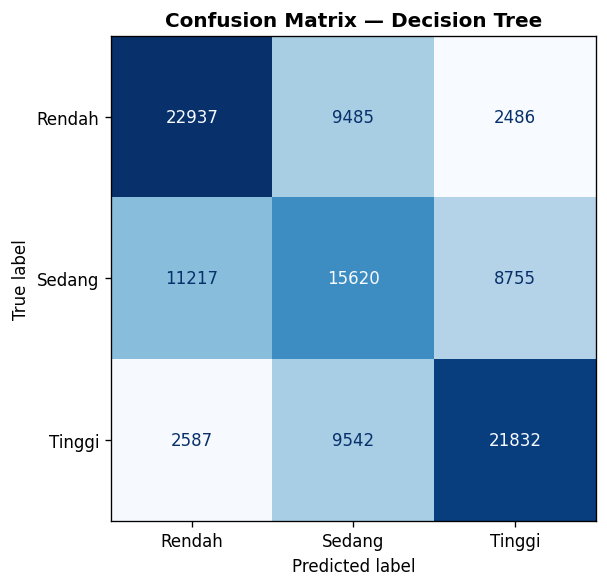

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,          # dibatasi agar tidak overfit
    min_samples_leaf=20,  # minimum sampel per daun
    random_state=42
)

dt_model.fit(X_train_c_sc, y_train_c)
y_pred_dt = dt_model.predict(X_test_c_sc)

print("\n=== DECISION TREE ===")
print(f"Accuracy : {accuracy_score(y_test_c, y_pred_dt):.4f}")
print(classification_report(
    y_test_c, y_pred_dt,
    target_names=['Rendah', 'Sedang', 'Tinggi']
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_dt),
    display_labels=['Rendah', 'Sedang', 'Tinggi']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Decision Tree', fontweight='bold')
plt.tight_layout()
plt.show()

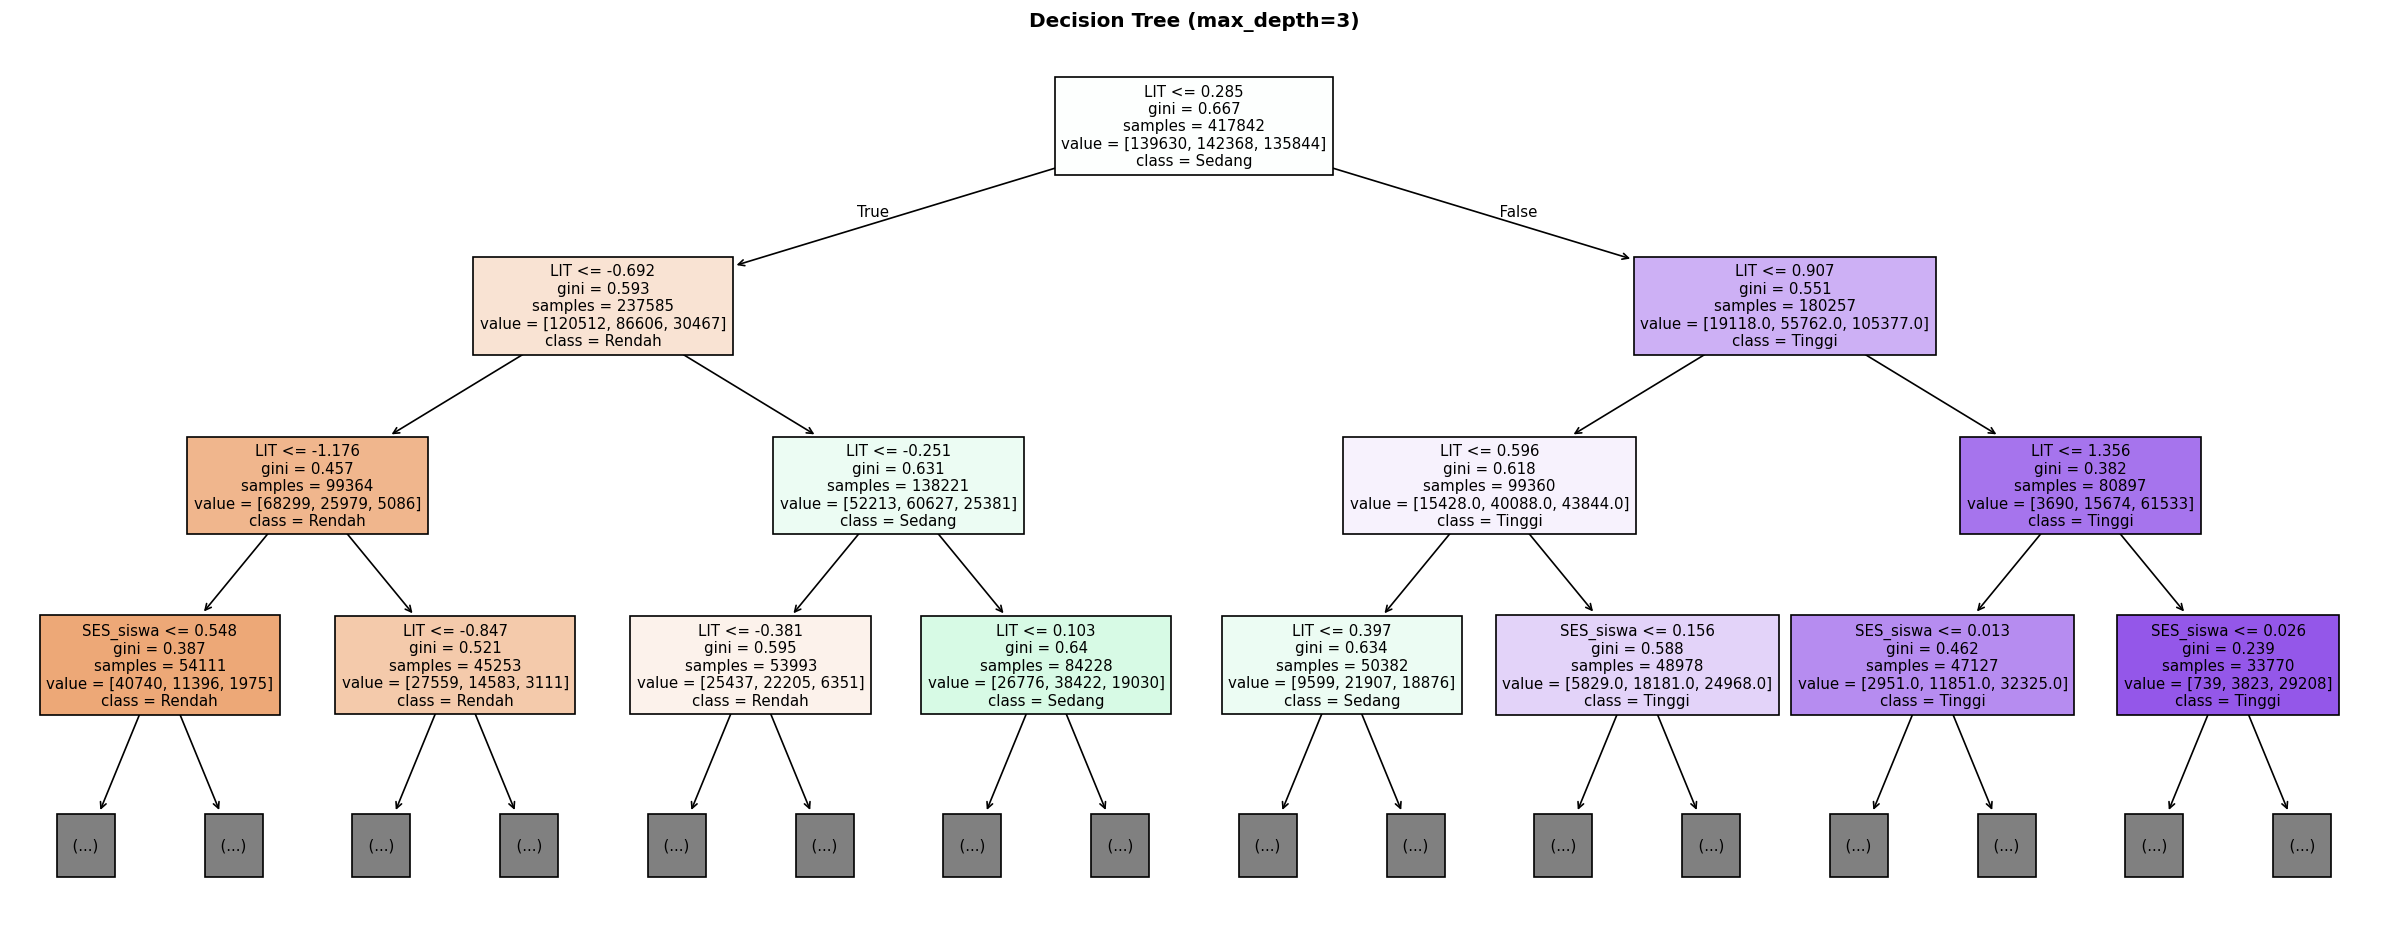

In [ ]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model, max_depth=3,
    feature_names=FITUR,
    class_names=['Rendah', 'Sedang', 'Tinggi'],
    filled=True, fontsize=9
)
plt.title('Decision Tree (max_depth=3)', fontweight='bold')
plt.tight_layout()
plt.show()

# 27. Random Forest Classifier


=== RANDOM FOREST CLASSIFIER ===
Accuracy : 0.5817
              precision    recall  f1-score   support

      Rendah       0.62      0.67      0.64     34908
      Sedang       0.46      0.41      0.43     35592
      Tinggi       0.65      0.68      0.66     33961

    accuracy                           0.58    104461
   macro avg       0.58      0.58      0.58    104461
weighted avg       0.58      0.58      0.58    104461



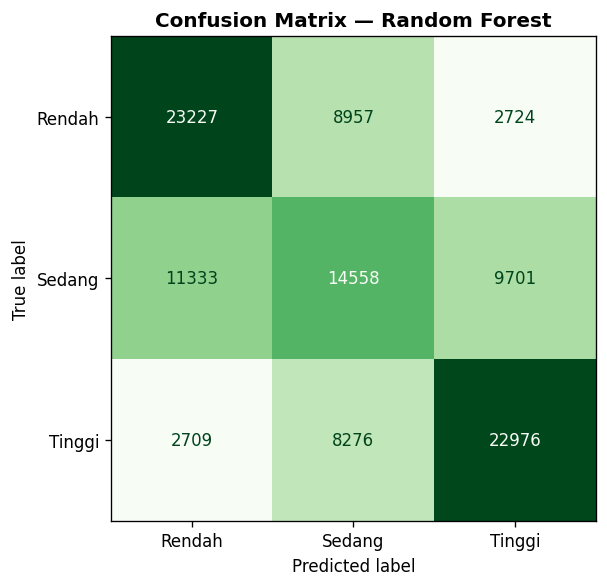

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_c_sc, y_train_c)
y_pred_rf = rf_model.predict(X_test_c_sc)

print("\n=== RANDOM FOREST CLASSIFIER ===")
print(f"Accuracy : {accuracy_score(y_test_c, y_pred_rf):.4f}")
print(classification_report(
    y_test_c, y_pred_rf,
    target_names=['Rendah', 'Sedang', 'Tinggi']
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_rf),
    display_labels=['Rendah', 'Sedang', 'Tinggi']
).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

# 28. Feature Importance (Random Forest)


=== FEATURE IMPORTANCE ===
                    Variabel  Importance
                         LIT    0.809358
                 SES_sekolah    0.054887
                   SES_siswa    0.048338
rasio_pendidik_peserta_didik    0.034850
             jumlah_pendidik    0.024151
           jumlah_komp_milik    0.020002
       ketersediaan_internet    0.005316
               jumlah_perpus    0.003098


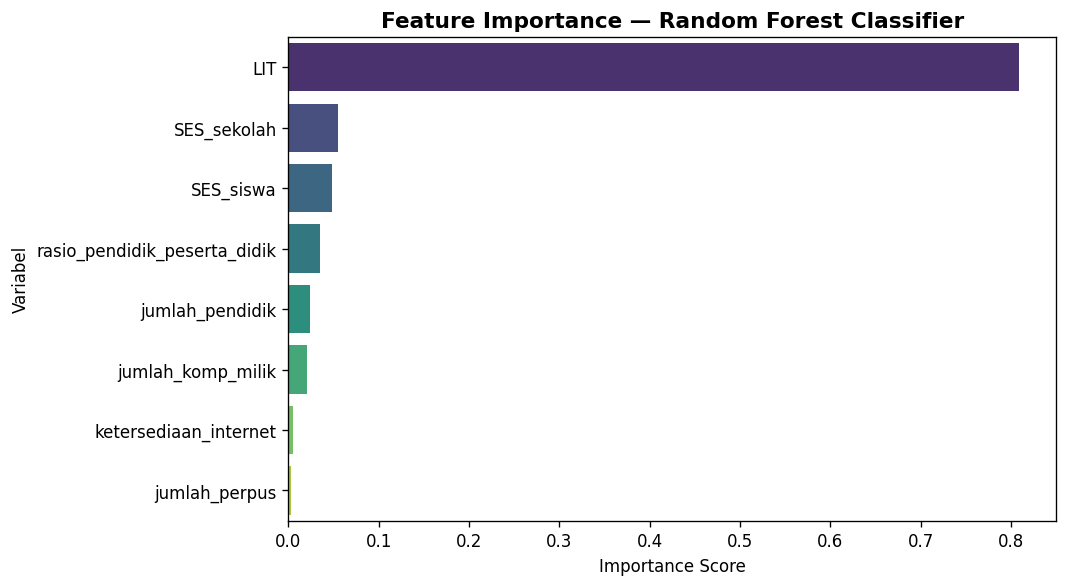

In [ ]:
importance = pd.DataFrame({
    'Variabel'  : FITUR,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n=== FEATURE IMPORTANCE ===")
print(importance.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=importance, x='Importance', y='Variabel',
    palette='viridis'
)
plt.title('Feature Importance — Random Forest Classifier',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 29. Perbandingan Accuracy: Decision Tree vs Random Forest

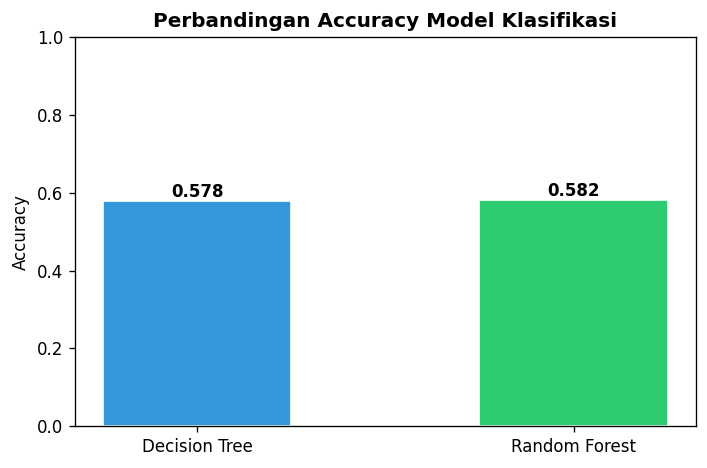

In [ ]:
acc_dt = accuracy_score(y_test_c, y_pred_dt)
acc_rf = accuracy_score(y_test_c, y_pred_rf)

plt.figure(figsize=(6, 4))
plt.bar(['Decision Tree', 'Random Forest'], [acc_dt, acc_rf],
        color=['#3498db', '#2ecc71'], edgecolor='white', width=0.5)
plt.ylim(0, 1)
plt.title('Perbandingan Accuracy Model Klasifikasi', fontweight='bold')
plt.ylabel('Accuracy')
for i, v in enumerate([acc_dt, acc_rf]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


# CLUSTERING

# 30. Persiapan Data Clustering

In [ ]:
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(X)

print(f"Data clustering: {X_cl.shape[0]} baris, {X_cl.shape[1]} fitur")

Data clustering: 522303 baris, 8 fitur


# 31. Elbow Method + Silhouette Score

In [ ]:
wcss = []

In [ ]:
sample_size = 30000

if len(X_cl) > sample_size:

    np.random.seed(42)

    idx = np.random.choice(
        len(X_cl),
        sample_size,
        replace=False
    )

    X_sample = X_cl[idx]

else:
    X_sample = X_cl

print(f"Jumlah data untuk clustering: {X_sample.shape[0]}")

Jumlah data untuk clustering: 30000



Menghitung Elbow & Silhouette (sabar sebentar)...
  k=2 selesai | silhouette=0.1514
  k=3 selesai | silhouette=0.1792
  k=4 selesai | silhouette=0.1630
  k=5 selesai | silhouette=0.1811
  k=6 selesai | silhouette=0.1807
  k=7 selesai | silhouette=0.1828
  k=8 selesai | silhouette=0.1840


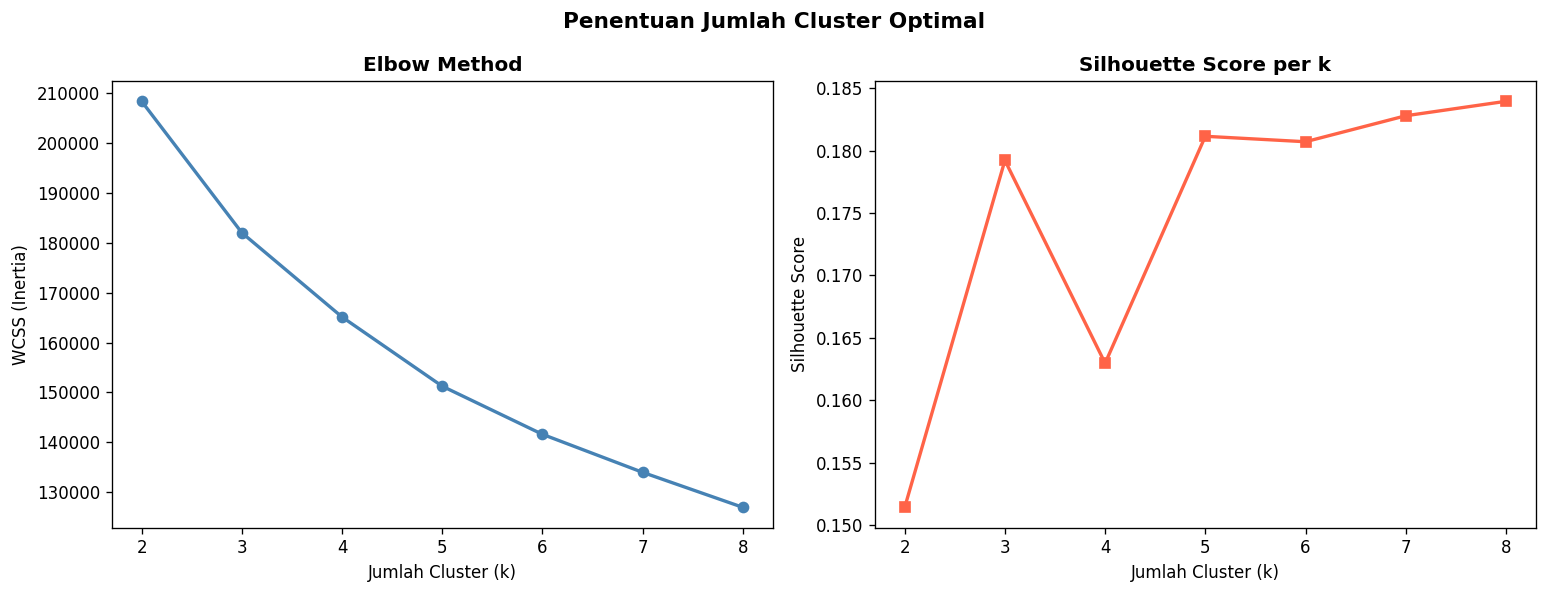


Silhouette Score tertinggi pada k = 8
→ Gunakan nilai k ini (atau sesuaikan dengan interpretasi domain)


In [ ]:
wcss       = []
sil_scores = []
K_range    = range(2, 9)   # 2–8 sudah cukup untuk eksplorasi

print("\nMenghitung Elbow & Silhouette (sabar sebentar)...")
for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=3,           # ← turun dari 10 → 3 (3-4x lebih cepat)
        algorithm='elkan'   # ← lebih cepat dari 'lloyd' untuk data padat
    )
    labels = km.fit_predict(X_sample)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5000))
    print(f"  k={k} selesai | silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, wcss, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('WCSS (Inertia)')

axes[1].plot(K_range, sil_scores, marker='s', color='tomato', linewidth=2)
axes[1].set_title('Silhouette Score per k', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Penentuan Jumlah Cluster Optimal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nSilhouette Score tertinggi pada k = {best_k}")
print("→ Gunakan nilai k ini (atau sesuaikan dengan interpretasi domain)")

In [ ]:
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nSilhouette Score tertinggi pada k = {best_k} (secara matematis)")

# Tampilkan perbandingan dengan k=3 (pilihan domain)
idx_k3 = list(K_range).index(3)
print(f"Silhouette Score pada k = 3  : {sil_scores[idx_k3]:.4f}")
print(f"Silhouette Score pada k = {best_k}  : {sil_scores[np.argmax(sil_scores)]:.4f}")
print(f"\n→ Dipilih k=3 berdasarkan pertimbangan domain:")
print(f"  Kategori 'Rendah/Sedang/Tinggi' lebih interpretatif untuk penelitian pendidikan.")
print(f"  Selisih silhouette score tidak signifikan secara praktis.")


Silhouette Score tertinggi pada k = 8 (secara matematis)
Silhouette Score pada k = 3  : 0.1792
Silhouette Score pada k = 8  : 0.1840

→ Dipilih k=3 berdasarkan pertimbangan domain:
  Kategori 'Rendah/Sedang/Tinggi' lebih interpretatif untuk penelitian pendidikan.
  Selisih silhouette score tidak signifikan secara praktis.


# 32. Model K-Means

In [ ]:
# k=3 dipilih atas dasar interpretabilitas domain (bukan k optimal matematis)
# Justifikasi: lihat perbandingan silhouette score di cell sebelumnya
N_CLUSTERS = 3

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=3,
    algorithm='elkan'
)

cluster_labels = kmeans.fit_predict(X_cl)
data['cluster'] = cluster_labels

# sample_size=5000 agar tidak hitung seluruh data
sil = silhouette_score(X_cl, cluster_labels, sample_size=5000)
print(f"\nSilhouette Score (k={N_CLUSTERS}): {sil:.4f}")
print("  (Semakin mendekati 1.0 = cluster semakin baik terpisah)")



Silhouette Score (k=3): 0.1522
  (Semakin mendekati 1.0 = cluster semakin baik terpisah)


# 33. Profil Tiap Cluster


=== PROFIL RATA-RATA TIAP CLUSTER ===
cluster                            0       1       2
LIT                           67.581  65.815  80.565
SES_siswa                     48.115  46.619  49.708
SES_sekolah                   71.569  67.008  76.638
ketersediaan_internet         -1.000   0.132   0.024
jumlah_komp_milik              5.000   4.071   8.851
jumlah_perpus                  1.000   0.999   1.168
jumlah_pendidik               16.000  13.362  32.993
rasio_pendidik_peserta_didik   0.070   0.100   0.063
NUM                           60.282  60.200  68.893


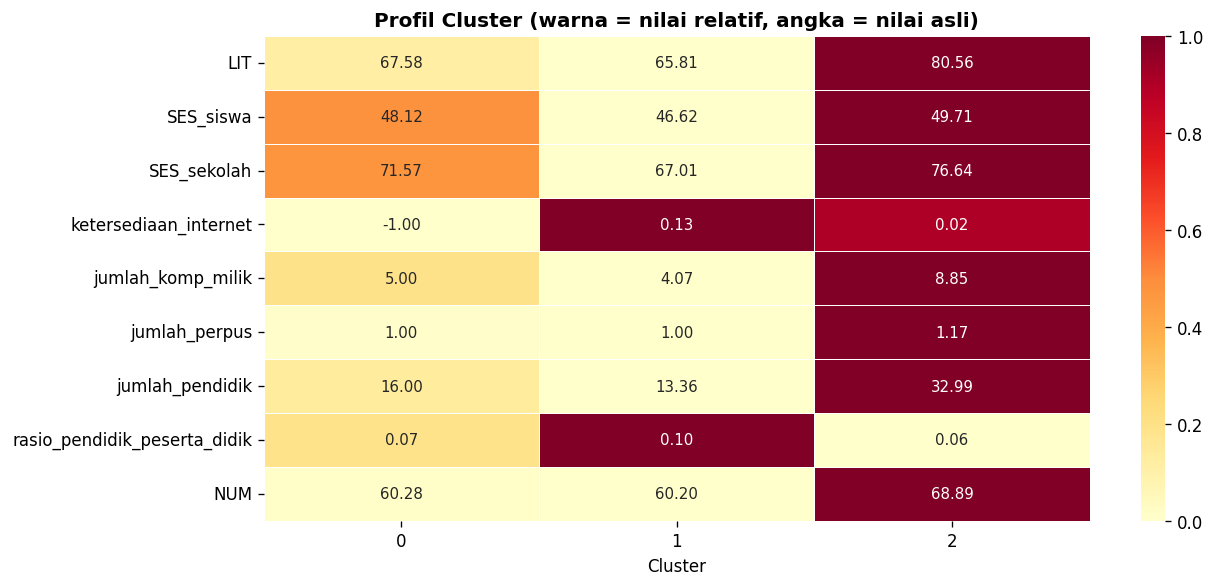

In [ ]:
cluster_profile = data.groupby('cluster')[FITUR + ['NUM']].mean().round(3)

print("\n=== PROFIL RATA-RATA TIAP CLUSTER ===")
print(cluster_profile.T.to_string())

# Heatmap profil cluster (nilai dinormalisasi agar mudah dibandingkan)
profile_norm = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(11, 5))
sns.heatmap(
    profile_norm.T,
    annot=cluster_profile.T,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Profil Cluster (warna = nilai relatif, angka = nilai asli)',
          fontsize=12, fontweight='bold')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# 34. Visualisasi Cluster: LIT vs NUM

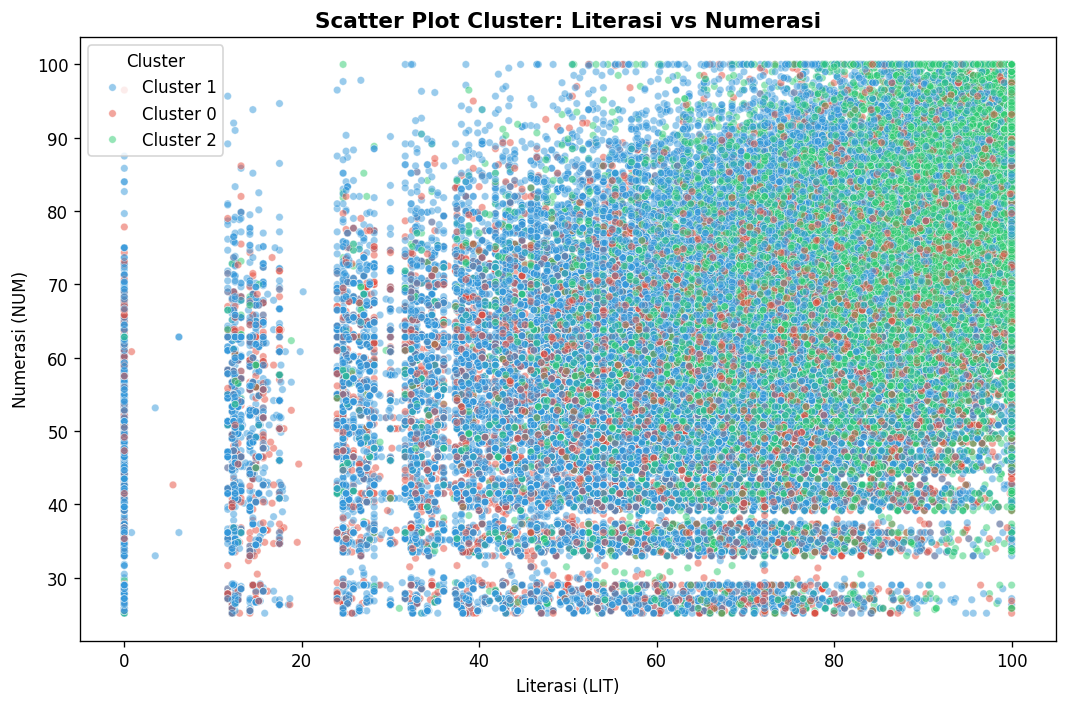

In [ ]:
plt.figure(figsize=(9, 6))
palette = {0: '#3498db', 1: '#e74c3c', 2: '#2ecc71'}
scatter = sns.scatterplot(
    x=data['LIT'], y=data['NUM'],
    hue=data['cluster'].map({i: f'Cluster {i}' for i in range(N_CLUSTERS)}),
    palette=list(palette.values()),
    alpha=0.5, s=20
)
plt.title('Scatter Plot Cluster: Literasi vs Numerasi',
          fontsize=13, fontweight='bold')
plt.xlabel('Literasi (LIT)')
plt.ylabel('Numerasi (NUM)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# 35. Visualiasi Cluster: PCA 2D

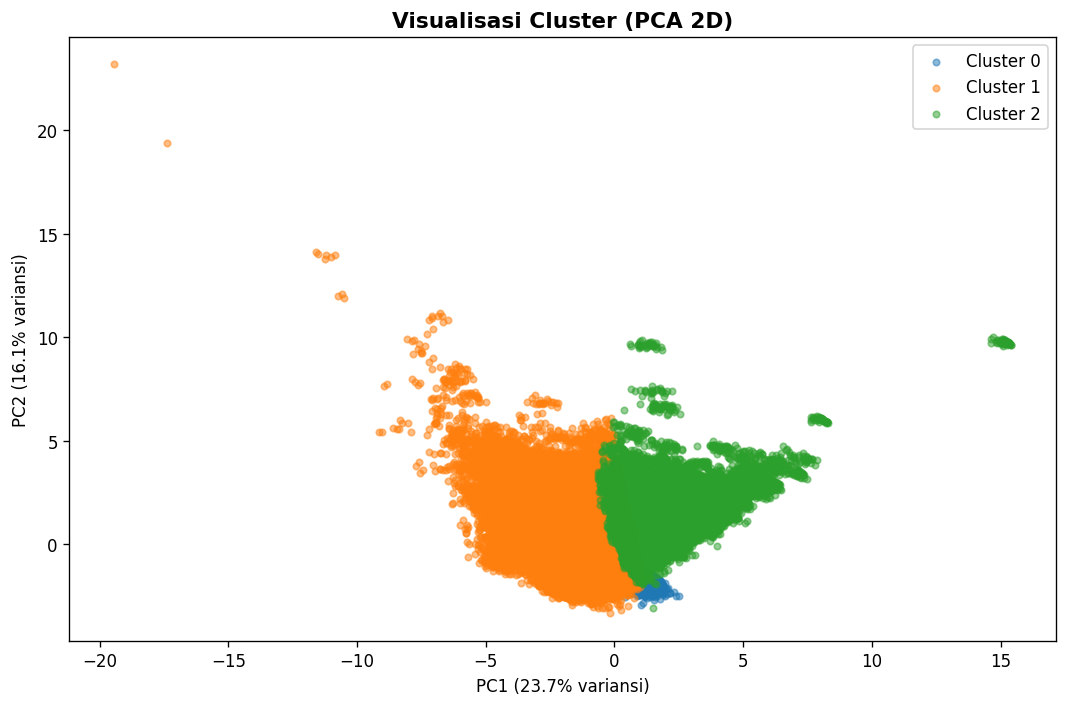


Total variansi yang dijelaskan 2 PC: 39.8%


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels

explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 6))
for cl in range(N_CLUSTERS):
    subset = pca_df[pca_df['cluster'] == cl]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cl}', alpha=0.5, s=15)
plt.xlabel(f'PC1 ({explained[0]:.1f}% variansi)')
plt.ylabel(f'PC2 ({explained[1]:.1f}% variansi)')
plt.title('Visualisasi Cluster (PCA 2D)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTotal variansi yang dijelaskan 2 PC: {explained.sum():.1f}%")

# 36. Distribusi Nilai NUM per Cluster

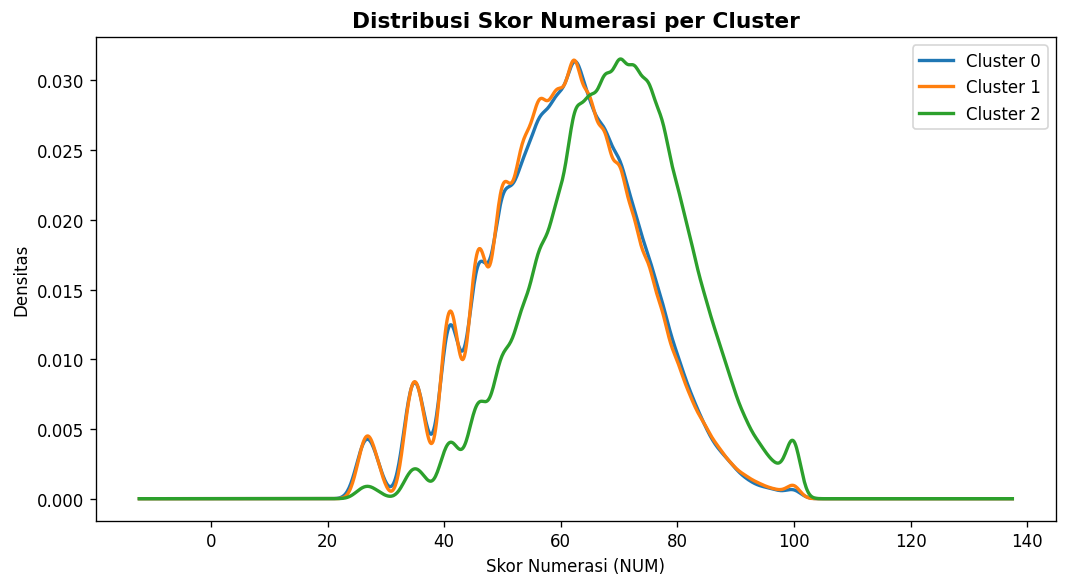

In [ ]:
plt.figure(figsize=(9, 5))
for cl in range(N_CLUSTERS):
    subset = data[data['cluster'] == cl]['NUM']
    subset.plot(kind='kde', label=f'Cluster {cl}', linewidth=2)
plt.title('Distribusi Skor Numerasi per Cluster',
          fontsize=13, fontweight='bold')
plt.xlabel('Skor Numerasi (NUM)')
plt.ylabel('Densitas')
plt.legend()
plt.tight_layout()
plt.show()

# 37. Interpretasi Hasil Cluster

In [ ]:
print("\n" + "="*60)
print("         INTERPRETASI CLUSTER (OTOMATIS SESUAI DATA)          ")
print("="*60)

cluster_info = []
for cl in range(N_CLUSTERS):
    mean_num = data[data['cluster'] == cl]['NUM'].mean()
    mean_lit = data[data['cluster'] == cl]['LIT'].mean()
    mean_ses = data[data['cluster'] == cl]['SES_siswa'].mean()
    mean_sess = data[data['cluster'] == cl]['SES_sekolah'].mean()
    n = (data['cluster'] == cl).sum()
    cluster_info.append({
        'cluster': cl, 'mean_num': mean_num, 'mean_lit': mean_lit,
        'mean_ses': mean_ses, 'mean_sess': mean_sess, 'n': n
    })

cluster_info_sorted = sorted(cluster_info, key=lambda x: x['mean_num'], reverse=True)

for i, c in enumerate(cluster_info_sorted):
    print(f"\nCluster {c['cluster']} ({c['n']} siswa):")
    print(f"   Rata-rata NUM        : {c['mean_num']:.2f}")
    print(f"   Rata-rata LIT        : {c['mean_lit']:.2f}")
    print(f"   Rata-rata SES_siswa  : {c['mean_ses']:.2f}")
    print(f"   Rata-rata SES_sekolah: {c['mean_sess']:.2f}")

    if i == 0: # Performanya nomor 1 (Tertinggi)
        print("   → Profil: Cluster ini menunjukkan siswa dengan kemampuan literasi dan numerasi yang TINGGI.")
        print("             Didukung oleh kondisi sekolah yang relatif baik, seperti jumlah komputer,")
        print("             jumlah pendidik, dan SES sekolah yang tinggi.")
    elif i == 1: # Performanya nomor 2 (Sedang)
        print("   → Profil: Cluster ini memiliki kemampuan numerasi dan literasi tingkat SEDANG.")
        print("             Meskipun kondisi sekolah cukup baik, capaian siswa tidak seoptimal kelompok tertinggi.")
    elif i == 2: # Performanya nomor 3 (Terendah)
        print("   → Profil: Cluster ini menunjukkan siswa dengan kemampuan numerasi dan literasi yang RENDAH.")
        print("             Cluster juga memiliki SES sekolah dan fasilitas teknologi yang paling terbatas.")


         INTERPRETASI CLUSTER (OTOMATIS SESUAI DATA)          

Cluster 2 (142814 siswa):
   Rata-rata NUM        : 68.89
   Rata-rata LIT        : 80.57
   Rata-rata SES_siswa  : 49.71
   Rata-rata SES_sekolah: 76.64
   → Profil: Cluster ini menunjukkan siswa dengan kemampuan literasi dan numerasi yang TINGGI.
             Didukung oleh kondisi sekolah yang relatif baik, seperti jumlah komputer,
             jumlah pendidik, dan SES sekolah yang tinggi.

Cluster 0 (122670 siswa):
   Rata-rata NUM        : 60.28
   Rata-rata LIT        : 67.58
   Rata-rata SES_siswa  : 48.12
   Rata-rata SES_sekolah: 71.57
   → Profil: Cluster ini memiliki kemampuan numerasi dan literasi tingkat SEDANG.
             Meskipun kondisi sekolah cukup baik, capaian siswa tidak seoptimal kelompok tertinggi.

Cluster 1 (256819 siswa):
   Rata-rata NUM        : 60.20
   Rata-rata LIT        : 65.81
   Rata-rata SES_siswa  : 46.62
   Rata-rata SES_sekolah: 67.01
   → Profil: Cluster ini menunjukkan siswa denga

In [ ]:
print("\n✅ Analisis selesai.")
print("   Variabel tersedia untuk eksplorasi lanjutan:")
print("   - data          : dataset lengkap + kolom cluster")
print("   - hasil_reg     : dict hasil regression")
print("   - dt_model      : Decision Tree model")
print("   - rf_model      : Random Forest Classifier model")
print("   - kmeans        : K-Means model")
print("   - cluster_profile: profil rata-rata tiap cluster")


✅ Analisis selesai.
   Variabel tersedia untuk eksplorasi lanjutan:
   - data          : dataset lengkap + kolom cluster
   - hasil_reg     : dict hasil regression
   - dt_model      : Decision Tree model
   - rf_model      : Random Forest Classifier model
   - kmeans        : K-Means model
   - cluster_profile: profil rata-rata tiap cluster
